# Linear Model in R

This notebook fits a simple linear model to salary data, reports slope, intercept, Pearson's *r*, and MSE, and displays an annotated ggplot2 regression plot.

## Step 1: Load libraries

Load ggplot2 for plotting and base R tools for modeling and summary statistics.

In [1]:
library(ggplot2)

## Step 2: Read and display the data

Load `regression_data.csv` and inspect the dataset.

In [2]:
data <- read.csv("regression_data.csv", stringsAsFactors = FALSE)
data

YearsExperience,Salary
<dbl>,<dbl>
1.1,39343
1.3,46205
1.5,37731
2.0,43525
2.2,39891
2.9,56642
3.0,60150
3.2,54445
3.7,57189


## Step 3: Explore the relationship

A scatter plot shows how salary changes with years of experience before fitting the model.

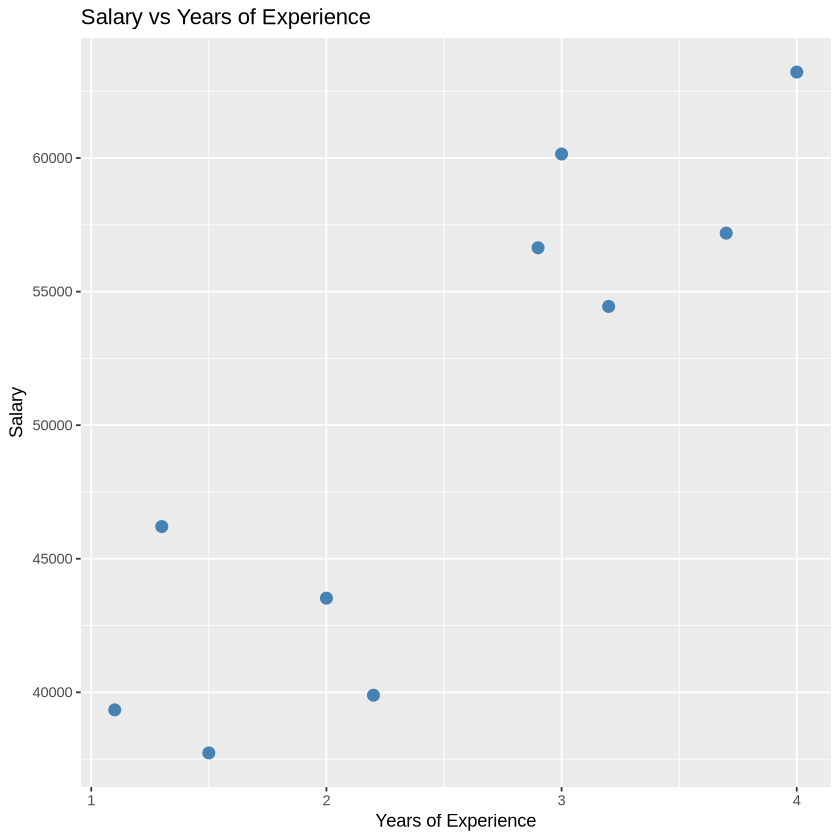

In [3]:
ggplot(data, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  labs(
    title = "Salary vs Years of Experience",
    x = "Years of Experience",
    y = "Salary"
  )

## Step 4: Fit the linear model

Fit `Salary ~ YearsExperience` with `lm()` and store the slope and intercept from the fitted model.

In [4]:
model <- lm(Salary ~ YearsExperience, data = data)

coefs <- coef(model)
intercept <- unname(coefs[1])
slope <- unname(coefs[2])

## Step 5: Predicted values

Compare each observed salary with the value predicted by the fitted line.

In [5]:
predictions <- data.frame(
  YearsExperience = data$YearsExperience,
  Observed_Salary = data$Salary,
  Predicted_Salary = predict(model),
  Residual = residuals(model)
)
predictions

,YearsExperience,Observed_Salary,Predicted_Salary,Residual
,<dbl>,<dbl>,<dbl>,<dbl>
1,1.1,39343,38317.34,1025.6560
2,1.3,46205,39974.40,6230.5976
3,1.5,37731,41631.46,-3900.4608
4,2.0,43525,45774.11,-2249.1069
5,2.2,39891,47431.17,-7540.1653
6,2.9,56642,53230.87,3411.1302
7,3.0,60150,54059.40,6090.6010
8,3.2,54445,55716.46,-1271.4574
9,3.7,57189,59859.10,-2670.1034


## Step 6: Regression statistics

Print the four required statistics from the fitted model: slope, intercept, Pearson's correlation coefficient (*r*), and MSE. R-squared is included only as an optional extra metric.

In [6]:
pearson_r <- cor(data$YearsExperience, data$Salary)
mse <- mean(residuals(model)^2)
r2 <- summary(model)$r.squared

cat(sprintf("Slope: %.4f\n", slope))
cat(sprintf("Intercept: %.4f\n", intercept))
cat(sprintf("Pearson's r: %.6f\n", pearson_r))
cat(sprintf("MSE: %.4f\n", mse))
cat(sprintf("R-squared (optional): %.6f\n", r2))

Slope: 8285.2921


Intercept: 29203.5227


Pearson's r: 0.886088


MSE: 17523844.0829


R-squared (optional): 0.785152


## Step 7: Annotated ggplot2 regression plot

Overlay the fitted line on the scatter plot and annotate the chart with the regression equation and key metrics.

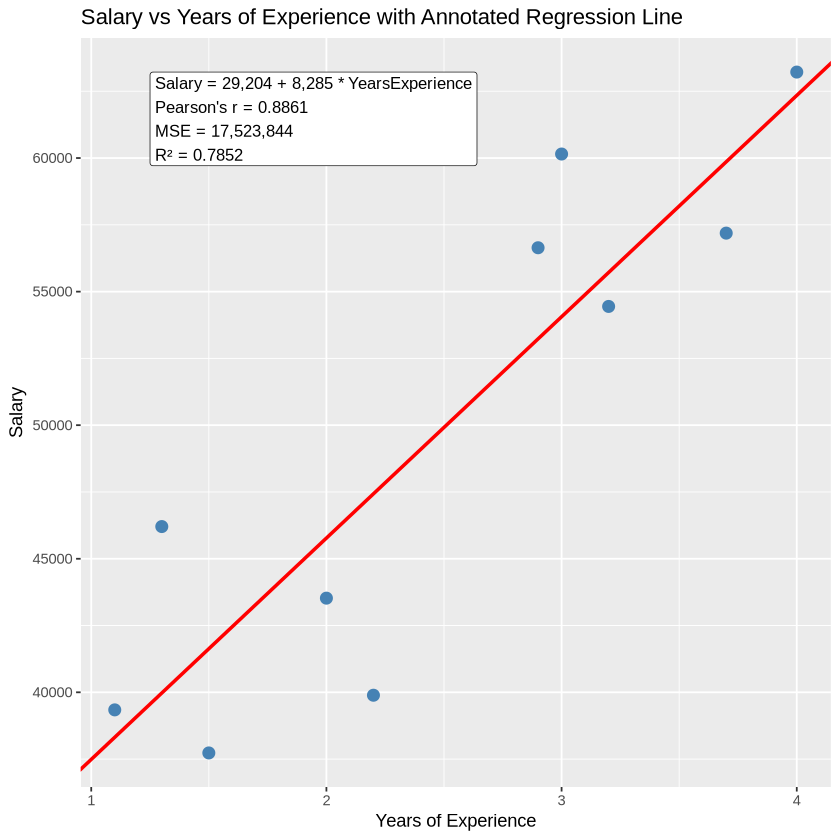

In [7]:
equation <- sprintf(
  "Salary = %s + %s * YearsExperience\nPearson's r = %.4f\nMSE = %s\nR² = %.4f",
  format(round(intercept), big.mark = ",", scientific = FALSE),
  format(round(slope), big.mark = ",", scientific = FALSE),
  pearson_r,
  format(round(mse), big.mark = ",", scientific = FALSE),
  r2
)

ggplot(data, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue", size = 3) +
  geom_abline(
    intercept = intercept,
    slope = slope,
    color = "red",
    linewidth = 1
  ) +
  annotate(
    "label",
    x = min(data$YearsExperience) + 0.15,
    y = max(data$Salary),
    label = equation,
    hjust = 0,
    vjust = 1,
    size = 3.5,
    linewidth = 0.2
  ) +
  labs(
    title = "Salary vs Years of Experience with Annotated Regression Line",
    x = "Years of Experience",
    y = "Salary"
  )